# Long-Term PM2.5 Projection (Scenario-Based)

This notebook generates a conditional long-term PM2.5 projection assuming recent environmental conditions persist. This is not a climate forecast.

In [ ]:
# Generate future synthetic timeline
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

# Load model
model = joblib.load("../models/random_forest_pm25.pkl")

# Load last known processed data
df = pd.read_csv("../data/processed/dongsi_ready_for_prediction.csv", index_col=0, parse_dates=True)
last_row = df.iloc[-1]

In [ ]:
# Create Future Time Index (5 Years Example)
future_hours = 5 * 365 * 24
future_index = pd.date_range(
    start=df.index[-1],
    periods=future_hours,
    freq="H"
)

C:\Users\ibaan\AppData\Local\Temp\ipykernel_2080\474532058.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_index = pd.date_range(


In [3]:
# Conditional rolling prediction
future_data = []

current = last_row.copy()

for ts in future_index:
    row = current.copy()

    # Update time features
    hour = ts.hour
    month = ts.month
    row["hour"] = hour
    row["month"] = month
    row["hour_sin"] = np.sin(2*np.pi*hour/24)
    row["hour_cos"] = np.cos(2*np.pi*hour/24)
    row["month_sin"] = np.sin(2*np.pi*month/12)
    row["month_cos"] = np.cos(2*np.pi*month/12)

    pred = model.predict(pd.DataFrame([row]))[0]
    future_data.append(pred)

    # Shift lag features
    row["PM2.5_lag_1h"] = pred
    current = row

C:\Users\ibaan\AppData\Local\Temp\ipykernel_2080\557432603.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_avg = future_series.resample("Y").mean()


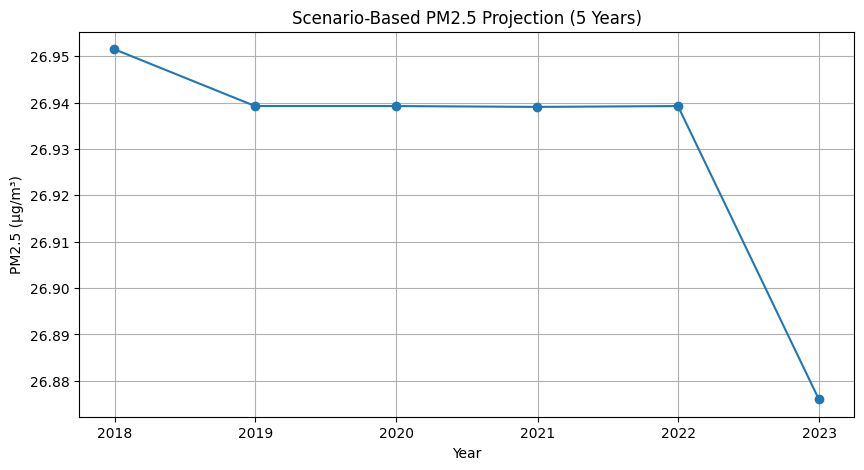

In [4]:
# Plot Projection (Downsampled)
future_series = pd.Series(future_data, index=future_index)

# Plot yearly average to keep graph readable
yearly_avg = future_series.resample("Y").mean()

plt.figure(figsize=(10,5))
plt.plot(yearly_avg, marker="o")
plt.title("Scenario-Based PM2.5 Projection (5 Years)")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Year")
plt.grid(True)
plt.show()